In [2]:
# import sys
# import os

# sys.path.append(os.path.abspath(".."))

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import nibabel as nib
import pandas as pd
import os
from tqdm import tqdm
import seaborn as sns

from constants_BHSD import *
from utils_BHSD import *

---
### Unlabel folder
---

In [4]:
print(UNLABEL_DIR)

/mnt/d/BHSD/unlabel_2000


In [5]:
unlabeled_path = os.path.join(DATASET_ROOT, UNLABEL_DIR)
files = os.listdir(unlabeled_path)
for file in files:
    print(file, ":" , len(os.listdir(os.path.join(unlabeled_path, file))))

anybleed : 562
nobleed : 1418


---
### Label folder
---

In [6]:
label_path = os.path.join(DATASET_ROOT, LABEL_DIR)
files = os.listdir(label_path)
for file in files:
    print(file, ":" , len(os.listdir(os.path.join(label_path, file))))

ground truths : 192
images : 192


In [7]:

unlabeled_path = os.path.join(DATASET_ROOT, UNLABEL_DIR)
rows = []

for folder in os.listdir(unlabeled_path):
    folder_path = os.path.join(unlabeled_path, folder)

    if not os.path.isdir(folder_path):
        continue

    files = os.listdir(folder_path)

    # lấy định dạng file
    formats = set()

    for f in files:
        if f.endswith(".nii.gz"):
            formats.add(".nii.gz")
        else:
            formats.add(os.path.splitext(f)[1])

    rows.append({
        "folder": folder,
        "num_files": len(files),
        "file_formats": ", ".join(formats),
    })

df = pd.DataFrame(rows)

df

,folder,num_files,file_formats
0,anybleed,562,.nii.gz
1,nobleed,1418,.nii.gz


In [8]:

labeled_path = os.path.join(DATASET_ROOT, LABEL_DIR)
rows = []

for folder in os.listdir(labeled_path):
    folder_path = os.path.join(labeled_path, folder)

    if not os.path.isdir(folder_path):
        continue

    files = os.listdir(folder_path)

    # lấy định dạng file
    formats = set()

    for f in files:
        if f.endswith(".nii.gz"):
            formats.add(".nii.gz")
        else:
            formats.add(os.path.splitext(f)[1])

    rows.append({
        "folder": folder,
        "num_files": len(files),
        "file_formats": ", ".join(formats),
    })

df = pd.DataFrame(rows)

df

,folder,num_files,file_formats
0,ground truths,192,.nii.gz
1,images,192,.nii.gz


In [9]:
file_path = os.path.join(labeled_path, "ground truths")
file = os.path.join(file_path, "ID_0b10cbee_ID_f91d6a7cd2.nii.gz")
nii_img = nib.load(file)
data = nii_img.get_fdata()
header = nii_img.header
print(header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 0
dim             : [  3 512 512  32   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.         0.488281   0.488281   5.2284584  0.         0.
  0.         0.       ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : np.bytes_(b'')
aux_file        : np.bytes_(b'')
qform_code      : scanner
sform_code      : scanner
quatern_b       : -0.0
quatern_c       : 0.9890158
quatern_d       : 0.147

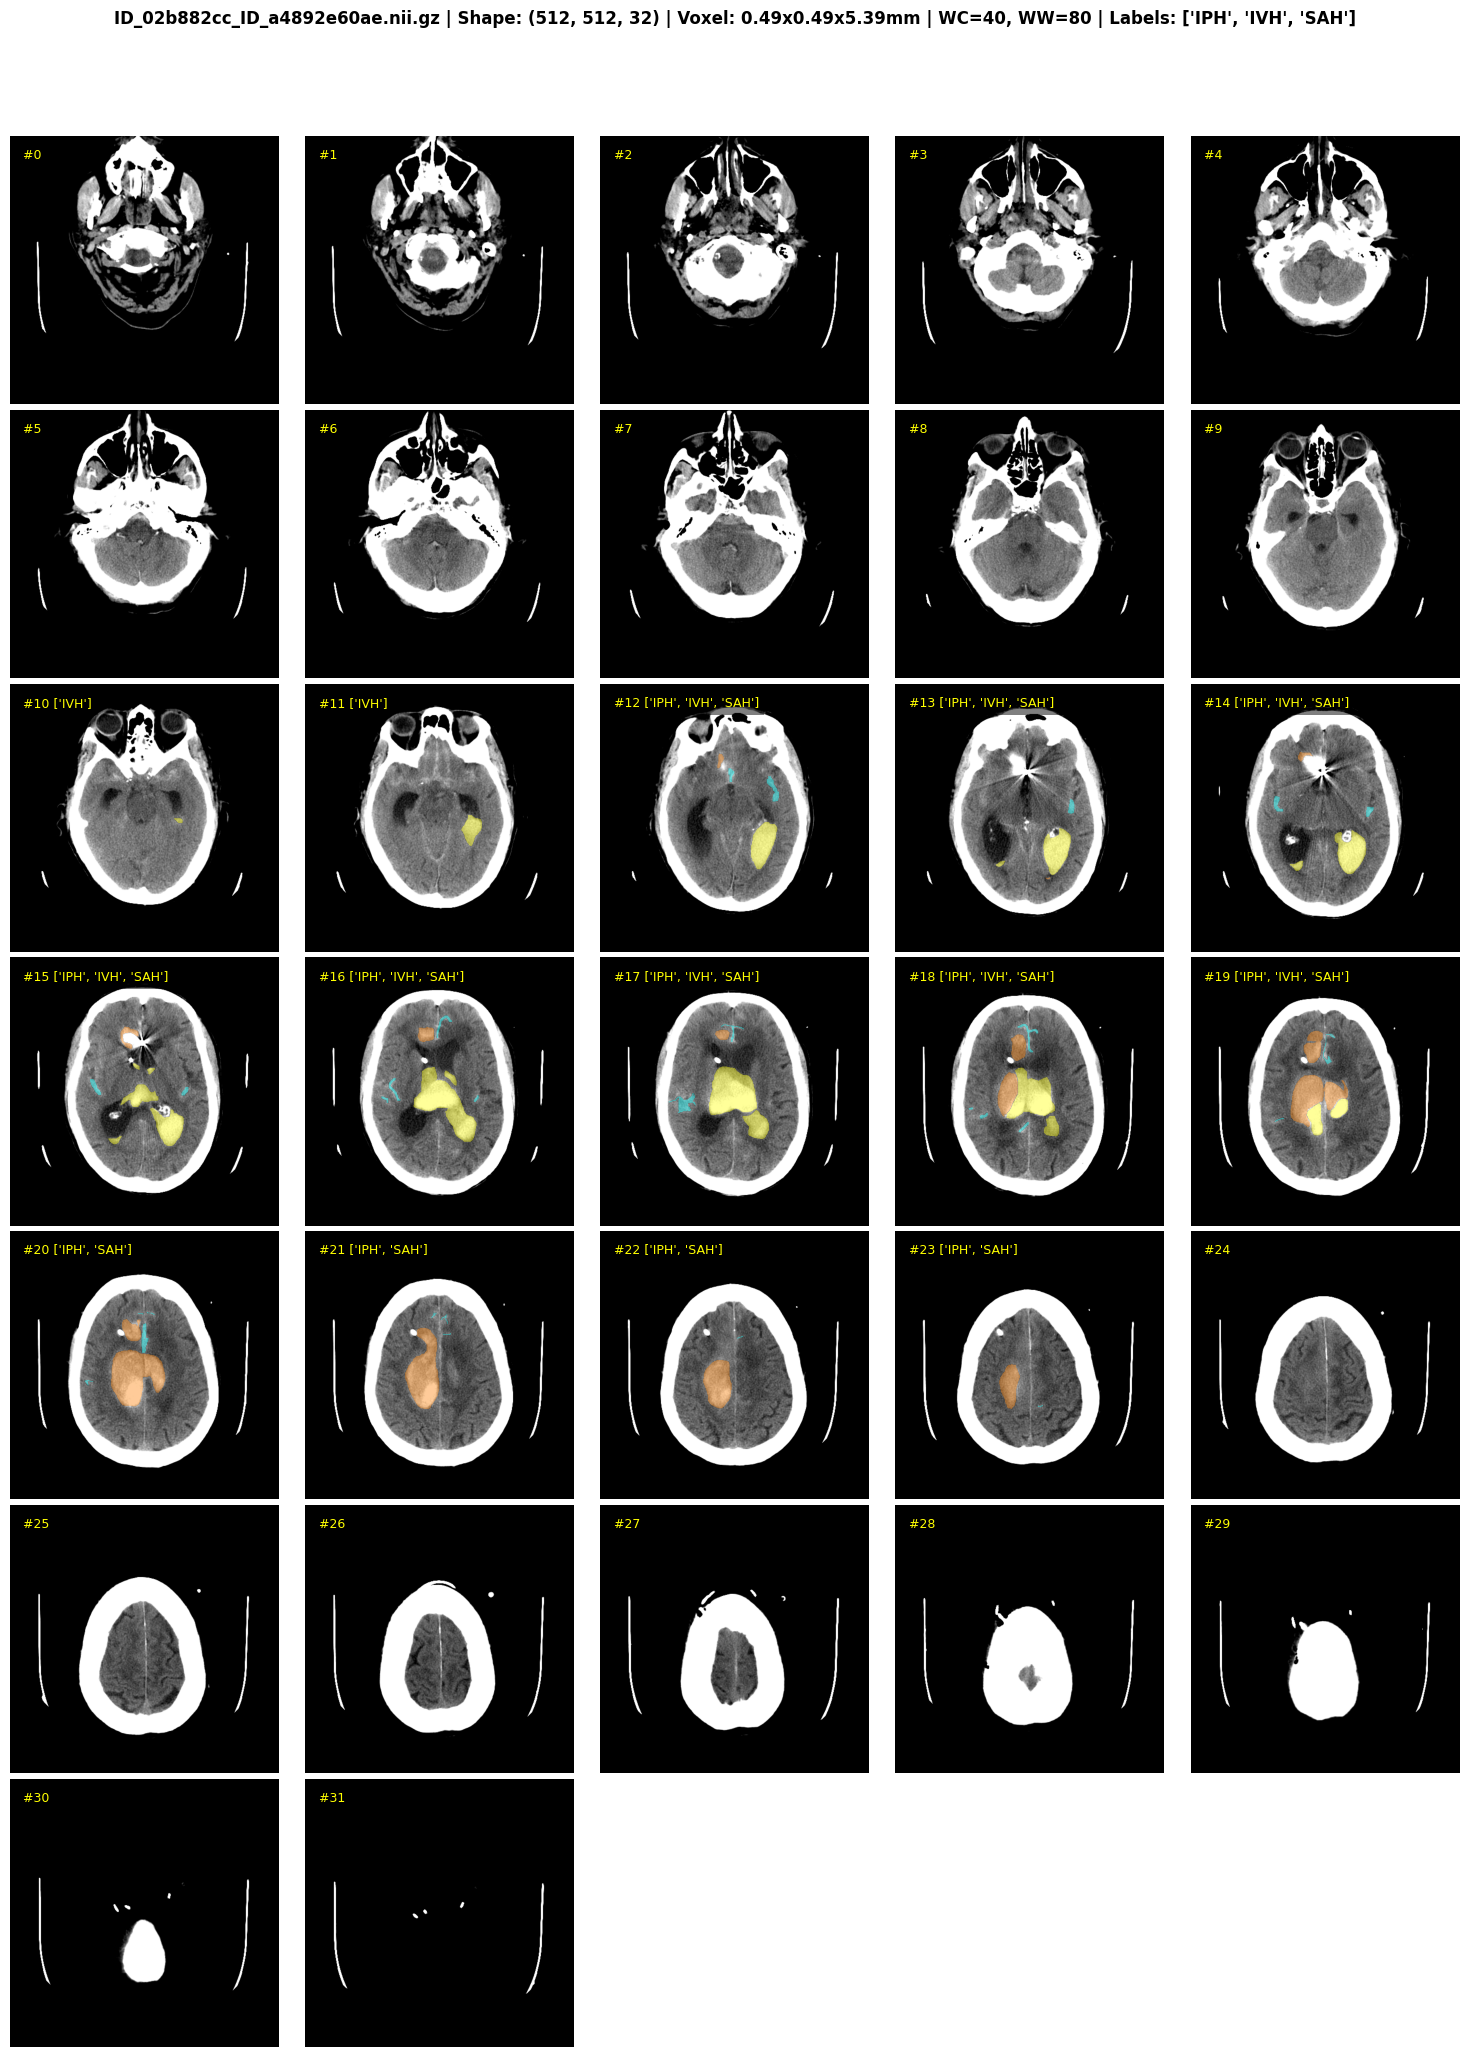

In [10]:
show_all_slices(
        "ID_02b882cc_ID_a4892e60ae.nii.gz",
        window=(40, 80),
        overlay=True
    )

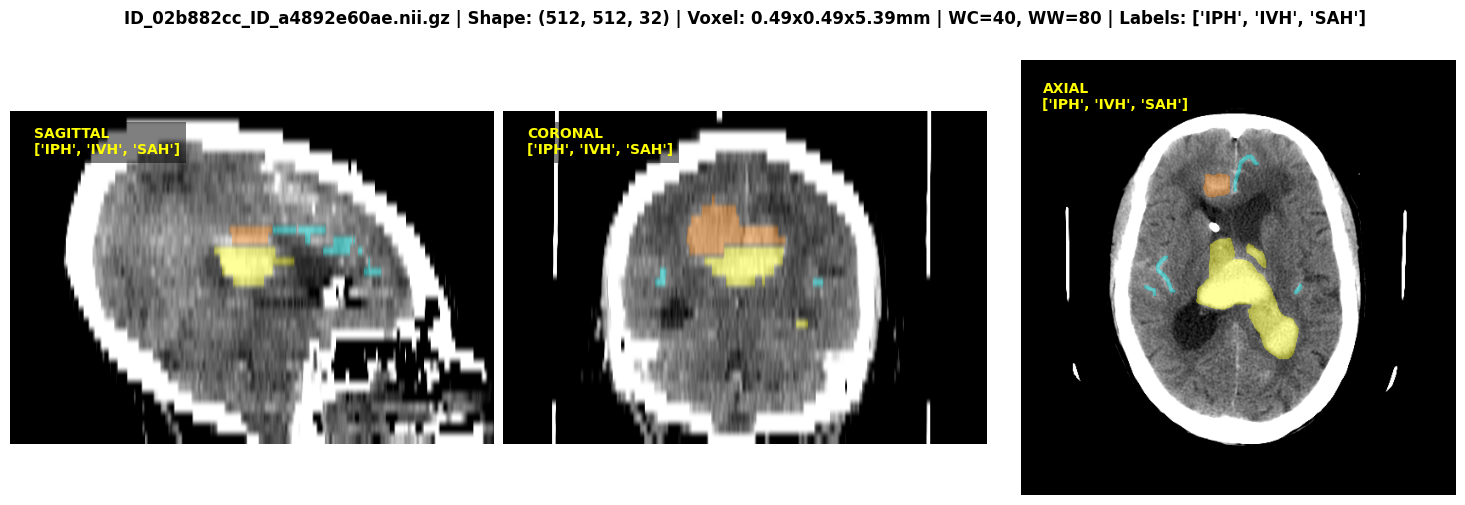

In [11]:
show_mid_slices(
        "ID_02b882cc_ID_a4892e60ae.nii.gz",
        window=(40, 80),
        overlay=True
    )

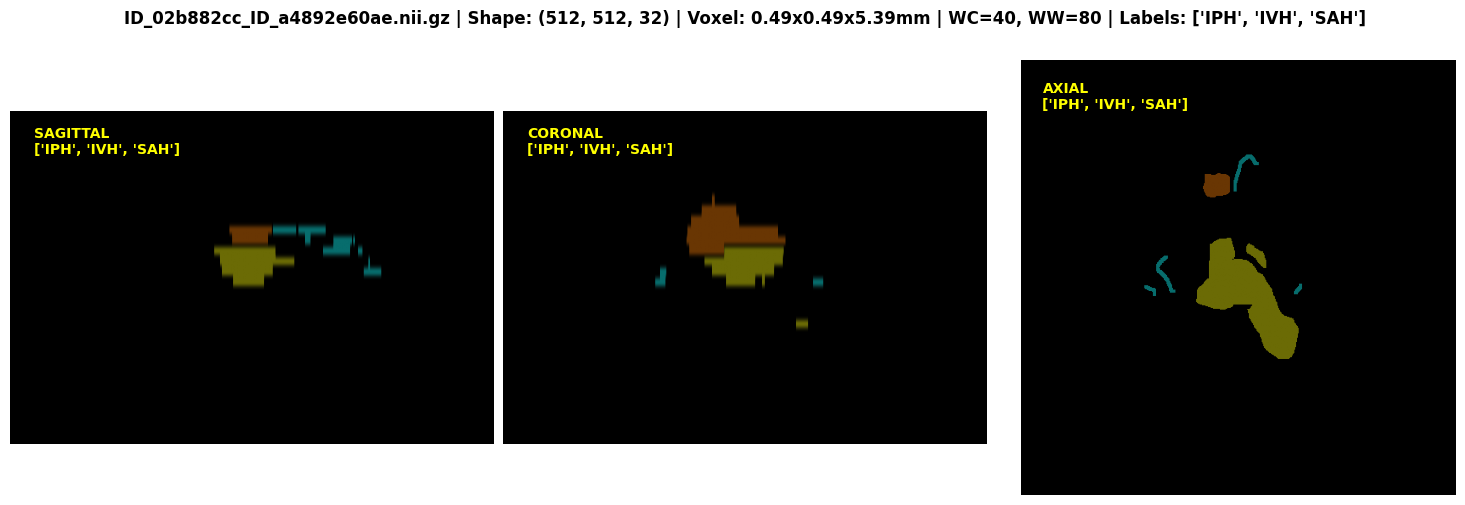

In [12]:
show_mid_slices(
    "ID_02b882cc_ID_a4892e60ae.nii.gz",
    window=(40, 80),
    overlay=True,
    base_dir=GROUND_TRUTH_DIR
)

In [13]:
df_header = pd.read_csv(HEADER_PATH)

Tìm thấy 192 file trong thư mục nhãn.


100%|██████████| 192/192 [00:22<00:00,  8.58it/s]


Khớp thành công 192 file.


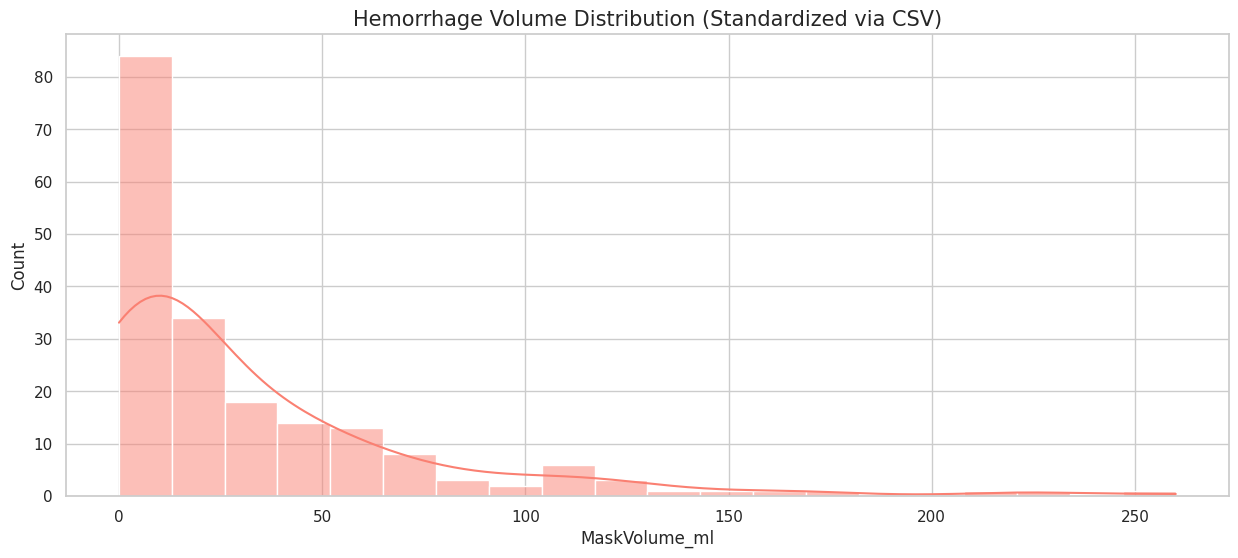

count    192.000000
mean      33.155478
std       43.733341
min        0.052452
25%        4.513416
50%       15.008682
75%       42.694193
max      260.022752
Name: MaskVolume_ml, dtype: float64


In [14]:
import os
import pandas as pd
import numpy as np
import nibabel as nib
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import ast

# 1. Khai báo đường dẫn
BASE_DIR = "/mnt/d/BHSD"
LABEL_DIR = os.path.join(BASE_DIR, "label_192/ground truths")
HEADER_CSV = "/home/thanh/Dataset/BHSD/header/BHSD_headers.csv"
# 2. Đọc và chuẩn hóa file CSV
df_header = pd.read_csv(HEADER_CSV)

# Hàm làm sạch tên file: loại bỏ đường dẫn và chỉ lấy phần ID chính
def clean_filename(path):
    # Lấy tên file từ đường dẫn, bỏ đuôi .nii.gz
    name = os.path.basename(path).replace('.nii.gz', '')
    # Nếu file nhãn có hậu tố (ví dụ _mask), bạn có thể thêm .replace('_mask', '') ở đây
    return name

df_header['clean_id'] = df_header['filename'].apply(clean_filename)

results = []

# 3. Quét thư mục nhãn
label_files = [f for f in os.listdir(LABEL_DIR) if f.endswith(".nii.gz")]
print(f"Tìm thấy {len(label_files)} file trong thư mục nhãn.")

for filename in tqdm(label_files):
    target_id = clean_filename(filename)
    
    # Tìm dòng tương ứng trong CSV
    header_row = df_header[df_header['clean_id'] == target_id]
    
    if not header_row.empty:
        # Lấy pxdim (đảm bảo đúng tên cột 'pxdim' như bạn mô tả)
        Pixdim_str = header_row.iloc[0]['pixdim']
        
        try:
            # Chuyển string '[...]' thành list
            pixdim = ast.literal_eval(Pixdim_str)
            spacing = (pixdim[1], pixdim[2], pixdim[3])
            voxel_unit_volume = np.prod(spacing)
            
            # Đọc file nhãn để đếm voxel
            file_path = os.path.join(LABEL_DIR, filename)
            label_data = nib.load(file_path).get_fdata()
            
            num_bleed_voxels = np.count_nonzero(label_data > 0)
            vol_ml = (num_bleed_voxels * voxel_unit_volume) / 1000.0
            
            results.append({
                "FileName": filename,
                "MaskVolume_ml": vol_ml
            })
        except Exception as e:
            print(f"Lỗi xử lý dữ liệu cho {filename}: {e}")
    else:
        # In ra để debug xem tại sao không khớp
        pass 

# 4. Kiểm tra kết quả
if results:
    df_volume = pd.DataFrame(results)
    df_filtered = df_volume[df_volume["MaskVolume_ml"] > 0]
    
    print(f"Khớp thành công {len(df_volume)} file.")
    
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(15, 6))
    sns.histplot(df_filtered["MaskVolume_ml"], kde=True, color="salmon")
    plt.title("Hemorrhage Volume Distribution (Standardized via CSV)", fontsize=15)
    plt.show()
    
    print(df_filtered["MaskVolume_ml"].describe())
else:
    print("Vẫn không tìm thấy dữ liệu khớp.")
    print(f"Ví dụ ID từ CSV: {df_header['clean_id'].iloc[0]}")
    print(f"Ví dụ ID từ thư mục: {clean_filename(label_files[0]) if label_files else 'None'}")

In [15]:
def collect_label_distribution(label_dir):
    """
    Duyệt qua tất cả volume, kiểm tra từng slice và ghi lại vị trí tương đối (%) 
    mà mỗi loại label xuất hiện.
    """
    label_files = [f for f in os.listdir(label_dir) if f.endswith(".nii.gz")]
    # Danh sách lưu các record: {'label': 'EDH', 'relative_pos': 45.5}
    distribution_data = []

    print(f"Đang phân tích {len(label_files)} volumes...")
    
    for filename in tqdm(label_files):
        file_path = os.path.join(label_dir, filename)
        label_vol = nib.load(file_path).get_fdata()
        
        n_slices = label_vol.shape[2] # Giả định slice nằm ở trục Z (axis 2)
        
        for i in range(n_slices):
            unique_labels = np.unique(label_vol[:, :, i])
            # Tính vị trí tương đối của slice này trong volume (0.0 -> 1.0)
            relative_pos = i / (n_slices - 1) if n_slices > 1 else 0
            
            for l in unique_labels:
                if l in LABEL_MAP and l != 0: # Bỏ qua background
                    distribution_data.append({
                        "Label": LABEL_MAP[l],
                        "Relative Position (%)": relative_pos * 100
                    })
                    
    return pd.DataFrame(distribution_data)

# Chạy thu thập dữ liệu
df_dist = collect_label_distribution(GROUND_TRUTH_DIR)

Đang phân tích 192 volumes...


100%|██████████| 192/192 [00:34<00:00,  5.53it/s]


In [16]:
df_dist.head()

,Label,Relative Position (%)
0,IPH,44.444444
1,IPH,48.148148
2,IPH,51.851852
3,IVH,51.851852
4,IPH,55.555556


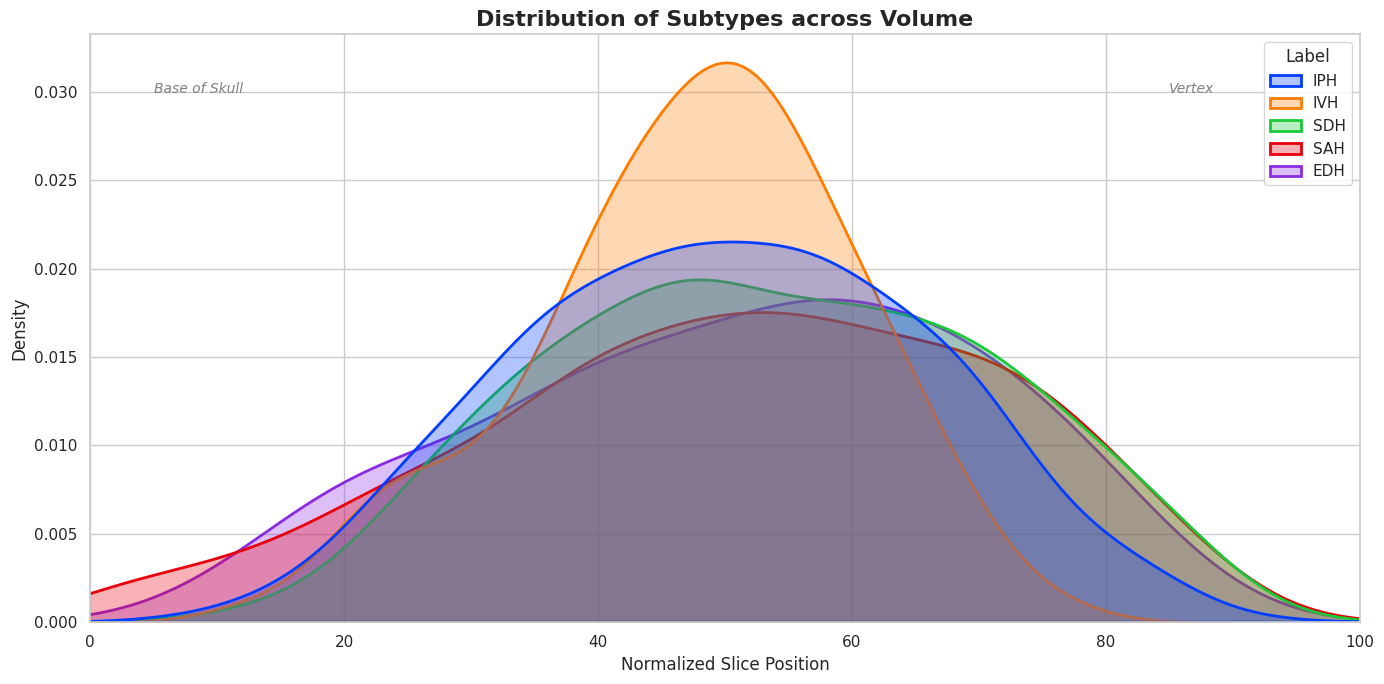

/tmp/ipykernel_8707/1532475897.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Relative Position (%)", y="Label", palette="Set2")


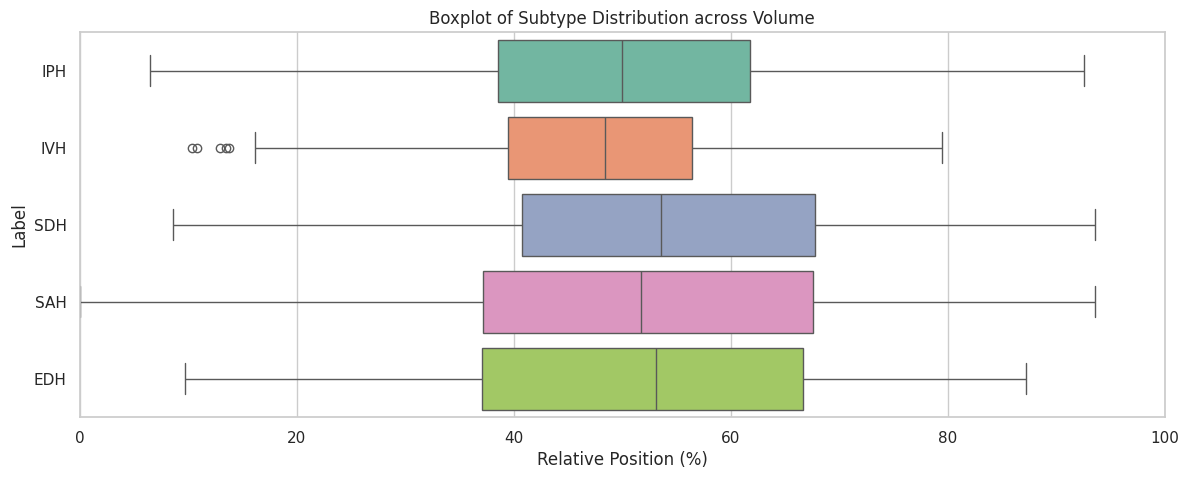

In [19]:
def plot_label_distribution(df):
    if df.empty:
        print("Không có dữ liệu để vẽ.")
        return

    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    # Vẽ biểu đồ mật độ (KDE)
    # x-axis: 0% là đáy sọ (vòm dưới), 100% là đỉnh đầu (vertex)
    ax = sns.kdeplot(
        data=df, 
        x="Relative Position (%)", 
        hue="Label", 
        common_norm=False, 
        palette="bright",
        fill=True,
        alpha=0.3,
        linewidth=2
    )

    plt.title("Distribution of Subtypes across Volume", fontsize=16, fontweight='bold')
    plt.xlabel("Normalized Slice Position", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.xlim(0, 100)
    
    # Thêm ghi chú cho các vùng
    plt.text(5, plt.ylim()[1]*0.9, "Base of Skull", color='gray', fontsize=10, fontstyle='italic')
    plt.text(85, plt.ylim()[1]*0.9, "Vertex", color='gray', fontsize=10, fontstyle='italic')

    plt.tight_layout()
    plt.show()

    # Thêm một biểu đồ Boxplot để xem dải phân bố rõ hơn
    plt.figure(figsize=(14, 5))
    sns.boxplot(data=df, x="Relative Position (%)", y="Label", palette="Set2")
    plt.title("Boxplot of Subtype Distribution across Volume")
    plt.xlim(0, 100)
    plt.show()

# Gọi hàm vẽ
plot_label_distribution(df_dist)